### **Bono 2: Extraer información climática contenida de la API de openweather y generar al menos un gráfico o tabla con estos datos.**

## Librerías

In [1]:
# Librerías
import requests
import pandas as pd
import matplotlib.pyplot as plt
# Para variables de entorno
import os
from dotenv import load_dotenv


## Configuración de la API

In [2]:
load_dotenv()

API_KEY = os.getenv('API_KEY')

## Diccionario con las coordenadas de distintas ciudades de Colombia

In [3]:
ciudades = {
    "Bogotá": {"lat": 4.6097, "lon": -74.0817},
    "Medellín": {"lat": 6.2442, "lon": -75.5812},
    "Cali": {"lat": 3.4516, "lon": -76.5320},
    "Santa Marta": {"lat": 11.2408, "lon": -74.1990},
    "Bucaramanga": {"lat": 7.1254, "lon": -73.1198}
}

datos_clima = []


##  Ciclo para obtener la información de cada ciudad

In [4]:
print("Obteniendo datos de la API...")
for nombre, coords in ciudades.items():
    #URL de la API de OpenWeatherMap para obtener el clima actual
    url = f"https://api.openweathermap.org/data/3.0/onecall?lat={coords['lat']}&lon={coords['lon']}&units=metric&lang=es&appid={API_KEY}"
    
    response = requests.get(url)
    
    if response.status_code == 200:
        data = response.json()
        #Extracción de la temperatura actual y la sensación térmica
        #Accede primero a 'current' para obtener los datos actuales del clima. current { temp: ..., feels_like:... , humidity:... }
        temp_actual = data['current']['temp']
        sensacion = data['current']['feels_like']
        humedad = data['current']['humidity']
        
        
        #Agregación de los datos a la lista para la creación del DataFrame
        datos_clima.append({
            "Ciudad": nombre,
            "Temperatura": temp_actual,
            "Sensación": sensacion,
            "Humedad": humedad
        })
    else:
        print(f"No se pudo obtener datos de {nombre}. Error: {response.status_code}")


Obteniendo datos de la API...


## Creación del DataFrame y la gráfica

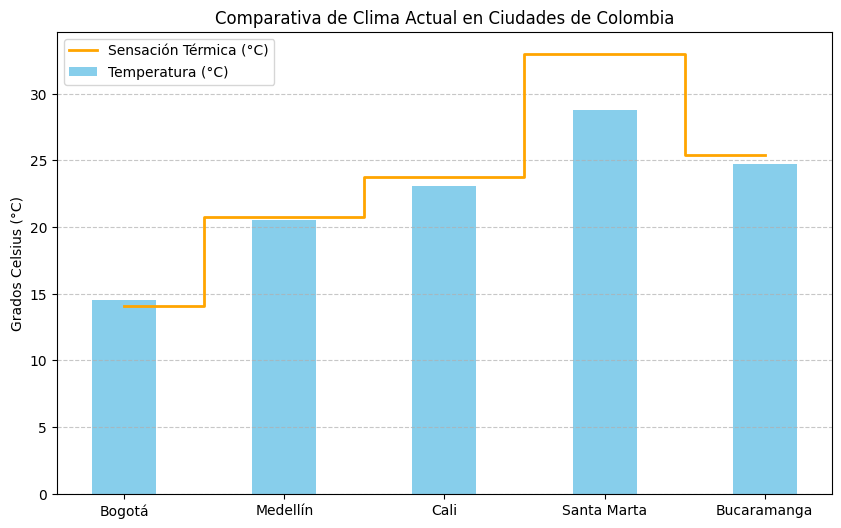


Tabla comparativa:
        Ciudad  Temperatura  Sensación  Humedad
0       Bogotá        14.54      14.11       79
1     Medellín        20.53      20.73       80
2         Cali        23.05      23.76       90
3  Santa Marta        28.79      32.99       74
4  Bucaramanga        24.70      25.42       84


In [5]:
if datos_clima:
    df = pd.DataFrame(datos_clima)
    
    #Configuración de la gráfica
    plt.figure(figsize=(10, 6))
    x = df['Ciudad']
    
    # Gráfica de Temperatura vs Sensación Térmica (Como el ser humano siente que hace más calor o frío que la temperatura real)
    plt.bar(x, df['Temperatura'], width=0.4, label='Temperatura (°C)', align='center', color='skyblue')
    plt.step(x, df['Sensación'], label='Sensación Térmica (°C)', where='mid', color='orange', linewidth=2)

    plt.title('Comparativa de Clima Actual en Ciudades de Colombia')
    plt.ylabel('Grados Celsius (°C)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.show()
    
    #Mostrar la tabla de datos
    print("\nTabla comparativa:")
    print(df)